Copyright (C) 2026 Manuel Cotelo Ferreiro (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid)

In [65]:
import argparse
import subprocess

import numpy as np
import pandas as pd

import scipy.interpolate
from scipy.spatial import distance_matrix

import h5py

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.path import Path

from tqdm import tqdm

from IPython.display import Video, display

In [66]:
import utils
import index

In [67]:
units = argparse.Namespace(
  s_to_ns=1e9, 
  m_to_nm=1e9, 
  m_to_micron=1e6,
  kg_to_g=1e3, 
  m3_to_l=1e3,
  K_to_eV=8.617333262145e-5,
)

In [69]:
file_name = 'dd_target_state.h5'
h5f = h5py.File(file_name, 'r')

In [ ]:
def get_time(ds):
  time = float(ds.attrs['time'][0])
  return time

In [ ]:
num_mats = 2
js = index.state_vars(num_mats)

class Worker():

  def __init__(self, h5f, js):
    self.h5f = h5f
    self.js = js
    return
  
  def __call__(self, ds_name):
    
    ds = self.h5f[ds_name]
    time = get_time(ds)

    vol = ds[:,:,self.js.vol]

    f1, f2 = ds[:,:,self.js.ms[0].f], ds[:,:,self.js.ms[1].f]
    fr1, fr2 = ds[:,:,self.js.ms[0].fr], ds[:,:,self.js.ms[1].fr]

    return {
      'time': time,
      'm1': np.sum(fr1 * vol),
      'v1': np.sum(f1  * vol),
      'm2': np.sum(fr2 * vol),
      'v2': np.sum(f2  * vol),
    }

worker = Worker(h5f, js)
items = pd.DataFrame([worker(ds_name) for ds_name in tqdm(h5f.keys())])

100%|██████████| 365/365 [00:15<00:00, 24.29it/s]


In [ ]:
items['d1'] = items['m1'] / items['v1']
items['d2'] = items['m2'] / items['v2']

Text(0, 0.5, '|M - M(0)| / M(0)')

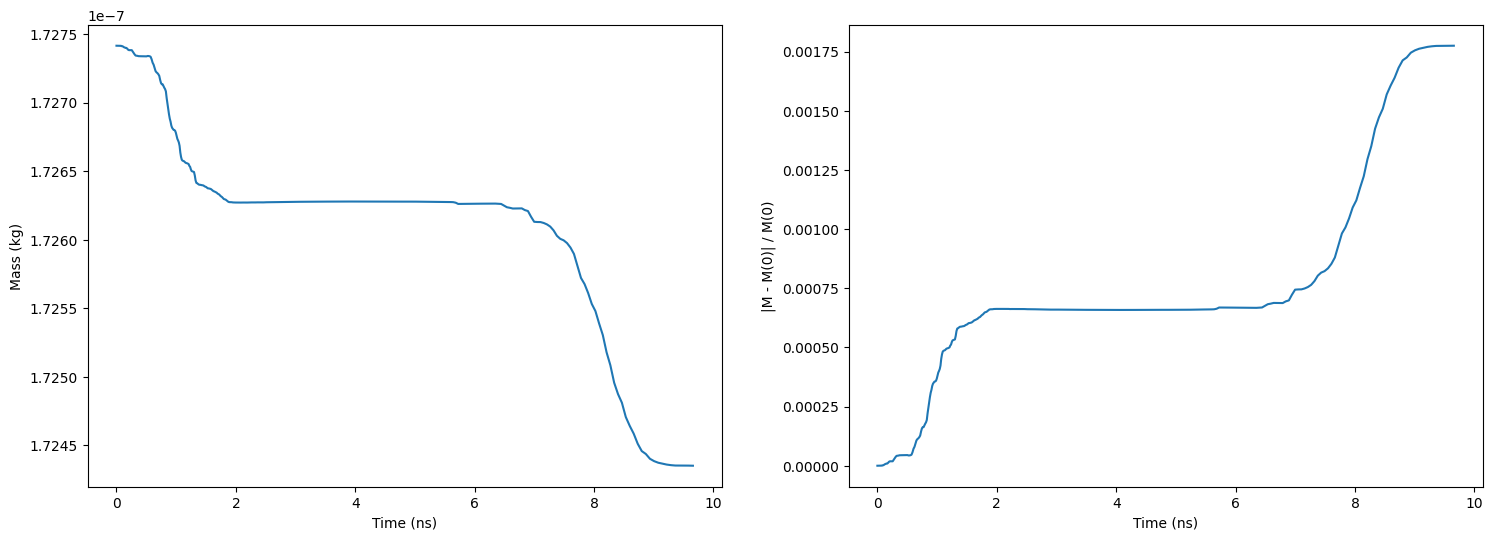

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].plot(items['time']*units.s_to_ns, items['m1'], label='d1')
ax[0].set_xlabel(r'Time (ns)')
ax[0].set_ylabel(r'Mass (kg)')

m_ref = items['m1'].iloc[0]
ax[1].plot(items['time']*units.s_to_ns, np.abs(1. - items['m1']/m_ref), label='d1')
ax[1].set_xlabel(r'Time (ns)')
ax[1].set_ylabel(r'|M - M(0)| / M(0)')

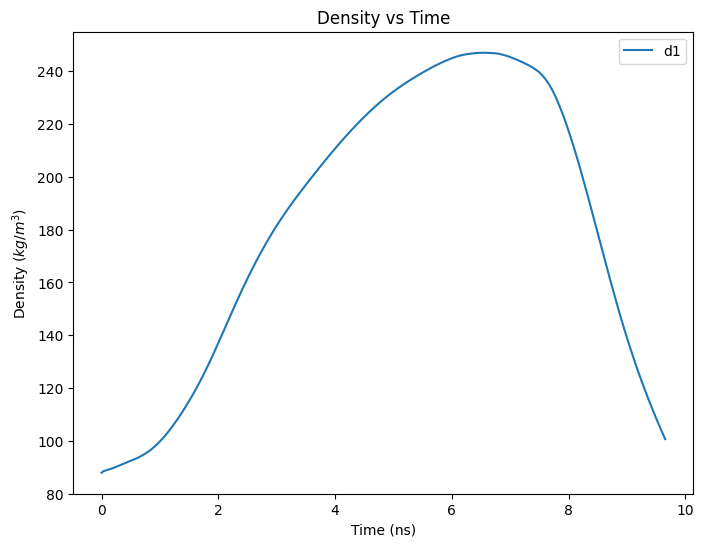

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(items['time']*units.s_to_ns, items['d1'], label='d1')
ax.set_xlabel(r'Time (ns)')
ax.set_ylabel(r'Density ($kg/m^3$)')
ax.set_title('Density vs Time')
ax.legend()

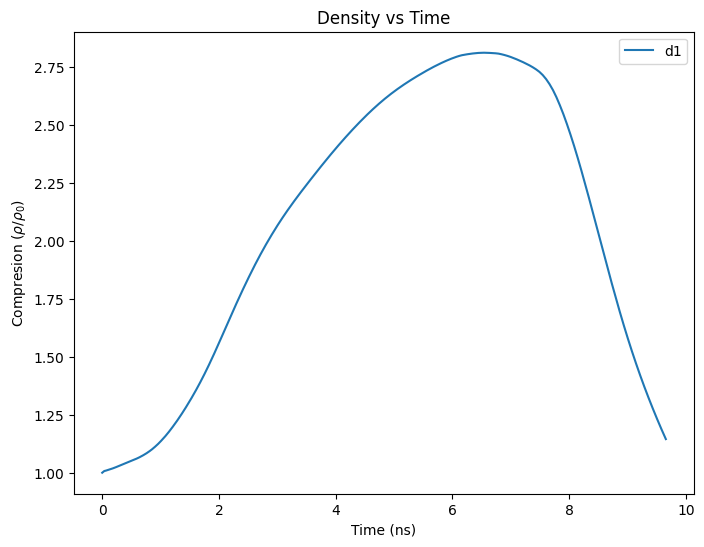

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

den_ref = items['d1'][0]

ax.plot(items['time']*units.s_to_ns, items['d1']/den_ref, label='d1')
ax.set_xlabel(r'Time (ns)')
ax.set_ylabel(r'Compresion ($\rho/\rho_0$)')
ax.set_title('Density vs Time')
ax.legend()

In [ ]:
ds_name = 'box_fine_cy000148'

ds = h5f[ds_name]

num_mats = 2
js = index.state_vars(num_mats)

In [ ]:
rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]

rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)
rs, zs = rc[0,:], zc[:,0]

vol = ds[:,:,js.vol]

den = ds[:,:,js.den]
pre = ds[:,:,js.pre]


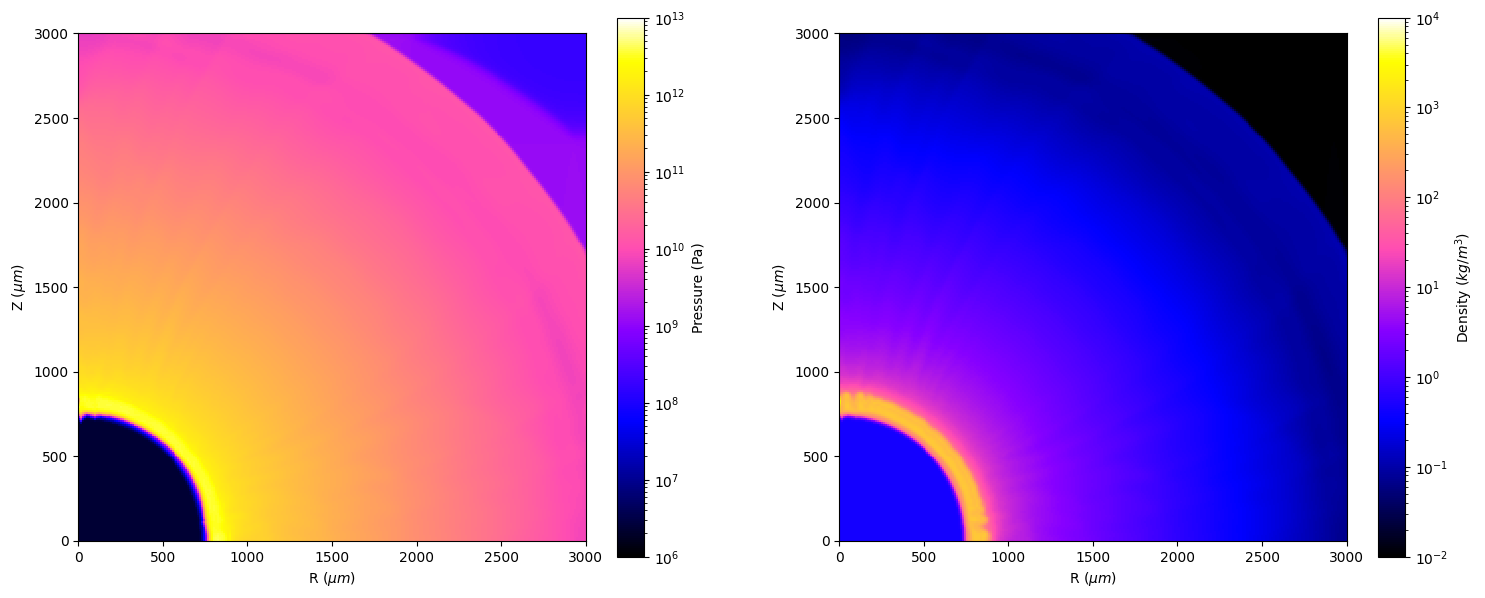

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

iml = ax[0].pcolormesh(rc*units.m_to_micron, zc*units.m_to_micron, pre, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e6, vmax = 1.e13))
cb = fig.colorbar(iml, ax=ax[0])
cb.set_label(r'Pressure (Pa)')
ax[0].set_xlabel(r'R ($\mu m$)')
ax[0].set_ylabel(r'Z ($\mu m$)')
ax[0].set_aspect('equal')

imr = ax[1].pcolormesh(rc*units.m_to_micron, zc*units.m_to_micron, den, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e-2, vmax = 1.e4))
cb = fig.colorbar(imr, ax=ax[1])
cb.set_label(r'Density ($kg/m^3$)')
ax[1].set_xlabel(r'R ($\mu m$)')
ax[1].set_ylabel(r'Z ($\mu m$)')
ax[1].set_aspect('equal')


In [ ]:
def lerp( x0, x1, y0, y1, y):
  """
  Linear interpolation between points (x0, y0) and (x1, y1) at point y.
  """
  assert np.abs(x1 - x0) > 1e-10, "x0 and x1 must be different for interpolation."
  a = (y1 - y0) / (x1 - x0)
  b = y0 - a*x0
  return (y - b) / a

def locate_val(arr, val, xs=None):
  """
  Locate the first index in `arr` where the value is greater than or equal to `val`.
  If `xs` is provided, return the corresponding value from `xs` instead of the index.
  """
  idx = np.searchsorted(arr, val, side='left')

  # check if not found
  if idx >= len(arr):
    return -1, arr[-1]
  elif idx == 0:
    return 0, arr[0]
  else:
    idx -= 1  # Adjust index to point to the last value less than `val`
    # linear interpolation to find the corresponding x value
    if xs is not None:
      return idx, lerp(xs[idx], xs[idx+1], arr[idx], arr[idx+1], val)
    else:
      return idx, lerp(idx, idx+1, arr[idx], arr[idx+1], val)


In [ ]:
num_mat = 2
js = index.state_vars(num_mat)

class RZ2SPH():

  def __init__(self, h5f, js):
    
    self.h5f = h5f
    self.js = js

    self.rs = np.linspace(1.e-6, 2.e-3, 400)
    self.ts = np.linspace(0, np.pi/2, 400)

    self.cs = np.cos(self.ts)
    self.sn = np.sin(self.ts)

    self.mx = np.array([ ri*self.sn for ri in self.rs ])
    self.mz = np.array([ ri*self.cs for ri in self.rs ])

    # assume all datasets have the same shape, so we can precompute the meshgrid for interpolation
    for ds_name in self.h5f.keys():
      self.rl, self.rh = self.h5f[ds_name][:,:,self.js.rl], self.h5f[ds_name][:,:,self.js.rh]
      self.zl, self.zh = self.h5f[ds_name][:,:,self.js.zl], self.h5f[ds_name][:,:,self.js.zh]
      self.rc, self.zc = 0.5*(self.rl+self.rh), 0.5*(self.zl+self.zh)
      self.vol = self.h5f[ds_name][:,:,self.js.vol]
      break

    self.dr = self.rc[1,0] - self.rc[0,0]
    self.dz = self.zc[0,1] - self.zc[0,0]

    self.ir = (self.mx - self.rc[0,0]) / self.dr
    self.jz = (self.mz - self.zc[0,0]) / self.dz
    self.coords_mapped = np.stack([ self.ir, self.jz ], axis=0, )

    self.func_interp = lambda arr: scipy.ndimage.map_coordinates(arr, self.coords_mapped, order=1, mode='nearest', prefilter=False)

    sw = np.sum(self.mx, axis=1, keepdims=True, )
    self.weight = self.mx / sw

    return
  
  def stats( self, x, ):
    mu = np.sum(x*self.weight, axis=1)
    x2 = np.sum(x**2*self.weight, axis=1)
    return mu, np.sqrt(x2 - mu**2)
  
  def __call__(self, ds_name):

    ds = self.h5f[ds_name]
    time = get_time(ds)

    den = ds[:,:,self.js.den]
    pre = ds[:,:,self.js.pre]
    tem = ds[:,:,self.js.tem]
    fvl = ds[:,:,self.js.fvcolor]

    den_interpolated = self.func_interp(den)
    pre_interpolated = self.func_interp(pre)
    tem_interpolated = self.func_interp(tem)
    fvl_interpolated = self.func_interp(fvl)

    d_mu, d_sigma = self.stats(den_interpolated)
    p_mu, p_sigma = self.stats(pre_interpolated)
    t_mu, t_sigma = self.stats(tem_interpolated)
    f_mu, f_sigma = self.stats(fvl_interpolated)

    ifv, rfv_mu = locate_val(f_mu, 1.5, xs=self.rs)

    return {
      'time': time,
      'ifv': ifv,
      'rfv_mu': rfv_mu,
      'data': np.array([ d_mu, d_sigma, p_mu, p_sigma, t_mu, t_sigma, f_mu, f_sigma ]).T,
    }

job = RZ2SPH(h5f, js)

list_steps = [ job(ds_name) for ds_name in tqdm(h5f) ]

  0%|          | 0/365 [00:00<?, ?it/s]C:\Users\clara\AppData\Local\Temp\ipykernel_26248\496544336.py:45: RuntimeWarning: invalid value encountered in sqrt
  return mu, np.sqrt(x2 - mu**2)
100%|██████████| 365/365 [00:25<00:00, 14.36it/s]


In [ ]:
time  = np.array([step['time']   for step in list_steps])
xf    = np.array([step['rfv_mu'] for step in list_steps])
steps = np.array([step['data']   for step in list_steps])

Text(0, 0.5, 'Time (ns)')

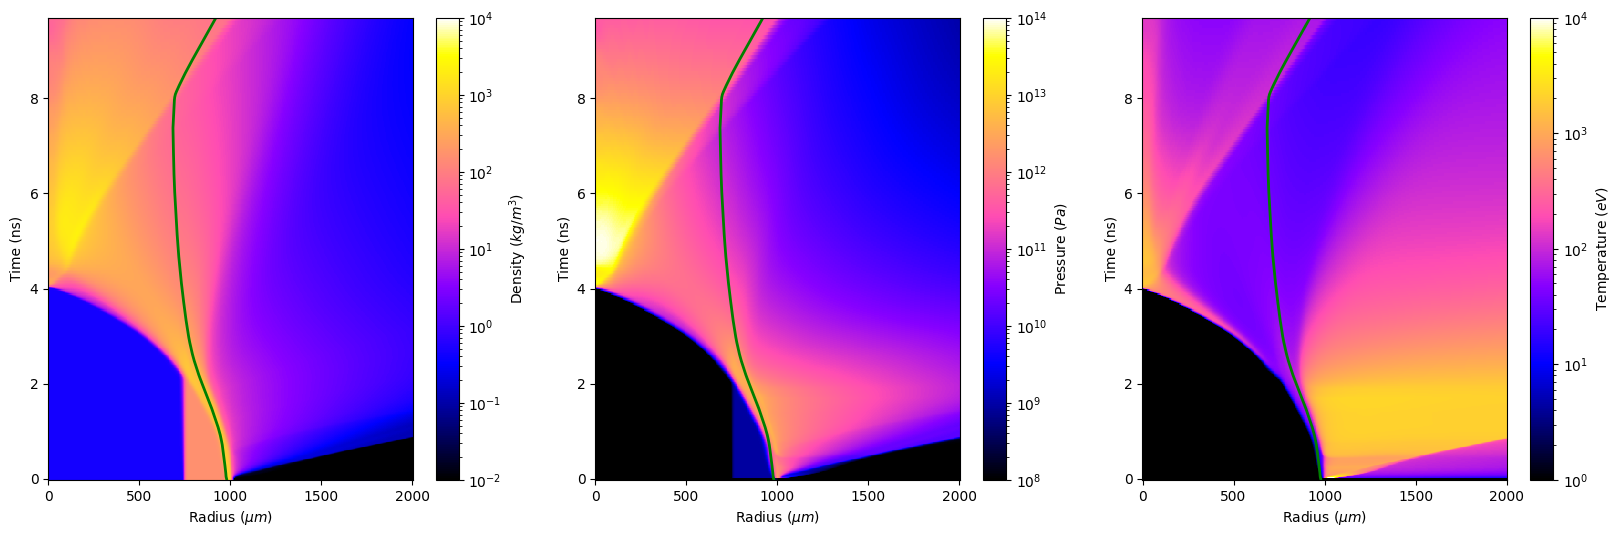

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

rs_micron = job.rs * units.m_to_micron
tm_ns = time * units.s_to_ns

im0 = ax[0].pcolormesh(rs_micron, tm_ns, steps[:,:,0], cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e-2, vmax = 1.e4))
cb0 = fig.colorbar(im0, ax=ax[0])
cb0.set_label(r'Density ($kg/m^3$)')
ax[0].plot( xf*units.m_to_micron, tm_ns, color='green', lw=2, label=r'$f_v = 0.5$')
ax[0].set_xlabel(r'Radius ($\mu m$)')
ax[0].set_ylabel(r'Time (ns)')

im1 = ax[1].pcolormesh(rs_micron, tm_ns, steps[:,:,2], cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e8, vmax = 1.e14))
cb1 = fig.colorbar(im1, ax=ax[1])
cb1.set_label(r'Pressure ($Pa$)')
ax[1].plot( xf*units.m_to_micron, tm_ns, color='green', lw=2, label=r'$f_v = 0.5$')
ax[1].set_xlabel(r'Radius ($\mu m$)')
ax[1].set_ylabel(r'Time (ns)')

im2 = ax[2].pcolormesh(rs_micron, tm_ns, steps[:,:,4], cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e0, vmax = 1.e4))
cb2 = fig.colorbar(im2, ax=ax[2])
cb2.set_label(r'Temperature ($eV$)')
ax[2].plot( xf*units.m_to_micron, tm_ns, color='green', lw=2, label=r'$f_v = 0.5$')
ax[2].set_xlabel(r'Radius ($\mu m$)')
ax[2].set_ylabel(r'Time (ns)')

100%|██████████| 365/365 [01:07<00:00,  5.39it/s]


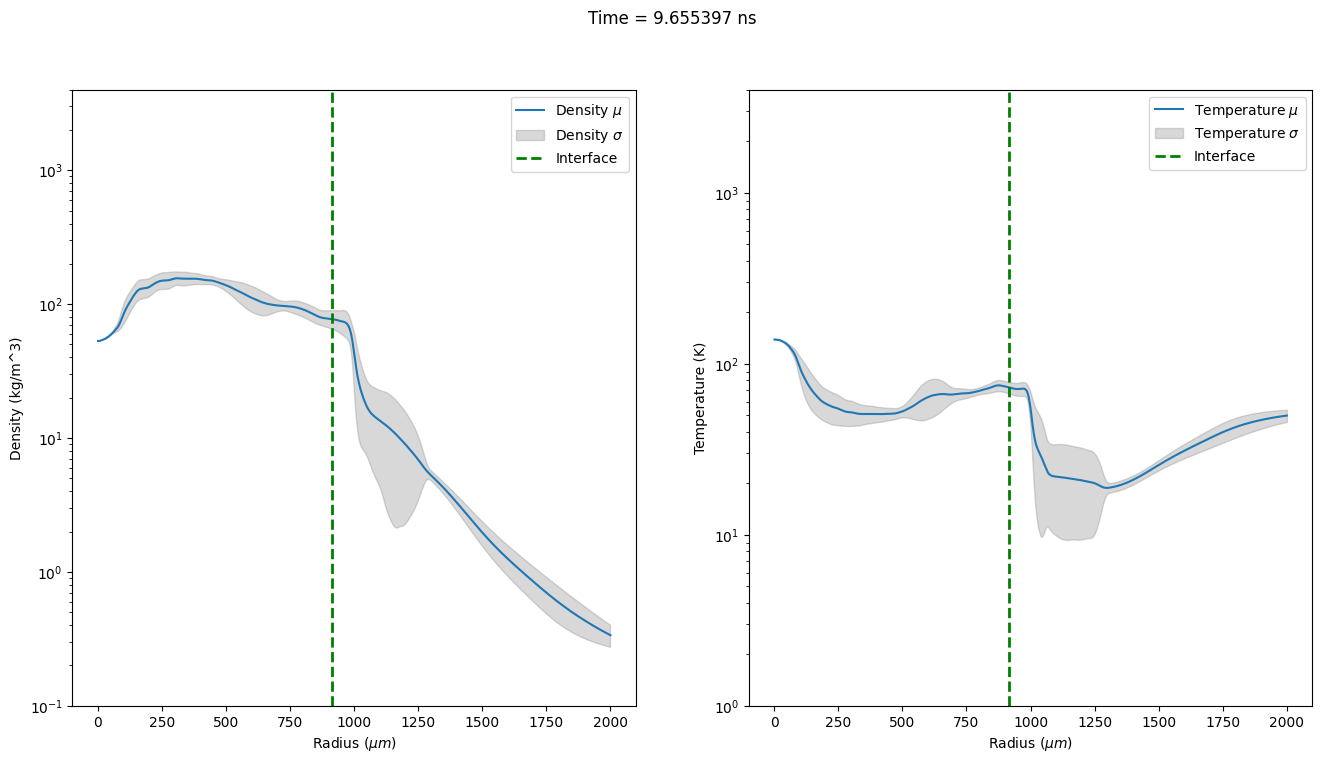

In [ ]:
# create video form steps

class UpdateFillBetween:
    def __init__(self, x, poly_collection):
        self.x = x
        self.poly_collection = poly_collection
        
        # Pre-allocate a vertex array to avoid re-allocating memory inside the loop
        # A simple closed polygon needs: forward points + backward points + 1 closing point
        self.vertices = np.zeros((2 * len(self.x) + 1, 2))
        
        # X coordinates never change, so assign them once in the constructor
        self.vertices[:len(self.x), 0] = self.x          # Forward X
        self.vertices[len(self.x):-1, 0] = self.x[::-1]  # Backward X
        self.vertices[-1, 0] = self.x[0]                 # Close to start X

    def __call__(self, y_lower, y_upper):
        # Update only the Y coordinates dynamically
        self.vertices[:len(self.x), 1] = y_upper          # Forward along the top
        self.vertices[len(self.x):-1, 1] = y_lower[::-1]  # Backward along the bottom
        self.vertices[-1, 1] = y_upper[0]                 # Close to start Y

        # Create a new Path object and assign it. 
        # Matplotlib will auto-generate the correct codes array behind the scenes.
        self.poly_collection.set_paths([ self.vertices, ])

class UpdateVerticalLine:
    def __init__(self, line_object):
        self.line_object = line_object

    def __call__(self, x_position):
        # axvline expects a list/array of the X position for both its top and bottom vertices
        self.line_object.set_xdata([x_position, x_position])

class Plotter():

    def __init__(self, job, list_steps, dpi=300, ):
        self.job = job
        self.list_steps = list_steps
        self.dpi = dpi

        self.fig, self.ax = plt.subplots(1, 2, figsize=(16, 8))

        self.rs_micron = job.rs * units.m_to_micron

        dummy = self.list_steps[0]['data'][:,0]  # Use the first step's density mean as a dummy for initialization

        self.p1 = self.ax[0].plot(self.rs_micron, dummy, label=r'Density $\mu$')[0]
        self.f1 = self.ax[0].fill_between(self.rs_micron, dummy-dummy, dummy+dummy, color='gray', alpha=0.3, label=r'Density $\sigma$')
        self.u1 = UpdateFillBetween(self.rs_micron, self.f1)
        self.i1 = UpdateVerticalLine(self.ax[0].axvline(0, color='green', linestyle='--', linewidth=2, label=r'Interface'))

        self.p2 = self.ax[1].plot(self.rs_micron, dummy, label=r'Temperature $\mu$')[0]
        self.f2 = self.ax[1].fill_between(self.rs_micron, dummy-dummy, dummy+dummy, color='gray', alpha=0.3, label=r'Temperature $\sigma$')
        self.u2 = UpdateFillBetween(self.rs_micron, self.f2)
        self.i2 = UpdateVerticalLine(self.ax[1].axvline(0, color='green', linestyle='--', linewidth=2, label=r'Interface')) 

        self.ax[0].set_ylim(1.e-1, 4.e3)
        self.ax[0].set_xlabel(r'Radius ($\mu m$)')
        self.ax[0].set_ylabel(r'Density (kg/m^3)')
        self.ax[0].set_yscale('log')
        self.ax[0].legend()

        self.ax[1].set_ylim(1.e0, 4.e3)
        self.ax[1].set_xlabel(r'Radius ($\mu m$)')
        self.ax[1].set_ylabel(r'Temperature (K)')
        self.ax[1].set_yscale('log')
        self.ax[1].legend()

        return

    def __call__(self, step_index, ):
        
        step = self.list_steps[step_index]

        time = step['time']
        xf   = step['rfv_mu']
        qs   = step['data']

        self.fig.suptitle(f'Time = {time*units.s_to_ns:.6f} ns')

        self.p1.set_ydata(qs[:,0])
        self.u1(qs[:,0]-qs[:,1], qs[:,0]+qs[:,1])
        self.i1(xf*units.m_to_micron)

        self.p2.set_ydata(qs[:,4])
        self.u2(qs[:,4]-qs[:,5], qs[:,4]+qs[:,5])
        self.i2(xf*units.m_to_micron)

        self.fig.savefig(f'frame_{step_index:06d}.png', dpi=self.dpi)

        return

plotter = Plotter(job, list_steps, dpi=100)
for i in tqdm(range(len(list_steps))):
  plotter(i)

In [ ]:
file_movie = 'output_video.mp4'

# Define the command as a list of strings
ffmpeg_cmd = [
    'ffmpeg',
    '-y',                      # Automatically overwrite output_video.mp4 if it already exists
    '-framerate', '30',        # Playback framerate
    '-i', 'frame_%06d.png',    # Input frame pattern
    '-c:v', 'libx264',         # Video codec
    '-crf', '17',              # High-quality setting
    '-pix_fmt', 'yuv420p',     # Pixel format for broad compatibility
    file_movie                 # Output file name
]

# Launch the command safely
try:
    # check=True will raise an error if FFmpeg fails, making debugging easier
    subprocess.run(ffmpeg_cmd, check=True)
    print(f"Video encoding complete! Created '{file_movie}'.")
except subprocess.CalledProcessError as e:
    print(f"An error occurred while running FFmpeg: {e}")
except FileNotFoundError:
    print("Error: 'ffmpeg' command not found. Make sure FFmpeg is installed and added to your system PATH.")


Video encoding complete! Created 'output_video.mp4'.


In [ ]:
video_player = Video(file_movie, embed=True, width=800, html_attributes="controls")
display(video_player)

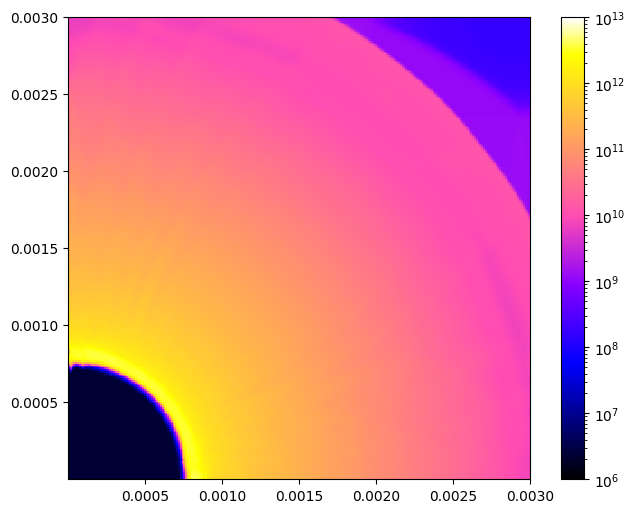

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.set_aspect('equal')
im = ax.pcolormesh(rc, zc, pre, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e6, vmax = 1.e13))
cb = fig.colorbar(im, ax=ax)

In [ ]:
from skimage.filters import meijering 
from skimage.morphology import skeletonize
from skimage.measure import label

!pip install skan

from skan import Skeleton, draw


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
ds_name = 'box_fine_cy000148'

ds = h5f[ds_name]

num_mats = 2
js = index.state_vars(num_mats)

In [ ]:
rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]

rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)
rs = rc[:,0]
zs = zc[0,:]

vol = ds[:,:,js.vol]

den = ds[:,:,js.den]
pre = ds[:,:,js.pre]


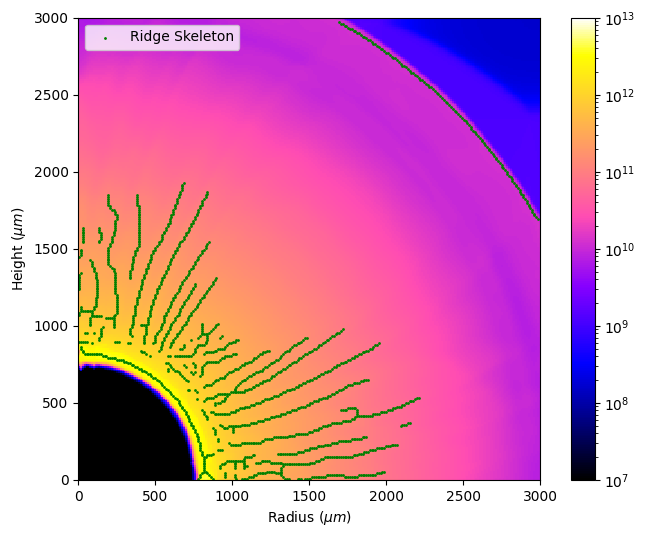

In [ ]:
# Assuming 'pressure_field' is your 2D numpy array...

# 1. Use Meijering or Frangi filter to highlight ridges/maxima lines
# This suppresses noise and enhances lines of continuous high values
ridges = meijering(pre, sigmas=[1, 2], black_ridges=False)  # Adjust sigmas based on the scale of features

# 2. Threshold the ridge map to create a binary mask
binary_mask = ridges > np.percentile(ridges, 90) # Adjust percentile to capture the ridge

# 3. Skeletonize to shrink the mask into a 1-pixel-wide line
line_skeleton = skeletonize(binary_mask)

# 4. Get the coordinates of the line
row_indices, col_indices = np.where(line_skeleton)
line_x = rs[col_indices]
line_y = zs[row_indices]

# Plotting the skeleton line over the original data
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_aspect('equal')
im = ax.pcolormesh(rc*units.m_to_micron, zc*units.m_to_micron, pre, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 1.e7, vmax = 1.e13))
cb = fig.colorbar(im, ax=ax)
#ax.pcolormesh(rc, zc, line_skeleton, cmap='plasma', shading='auto', norm=colors.LogNorm(vmin = 1.e6, vmax = 1.e13))
ax.scatter(line_x*units.m_to_micron, line_y*units.m_to_micron, color='green', s=1, label='Ridge Skeleton')
ax.set_xlabel(r'Radius ($\mu m$)')
ax.set_ylabel(r'Height ($\mu m$)')
ax.legend()

Text(0, 0.5, 'Z ($\\mu m$)')

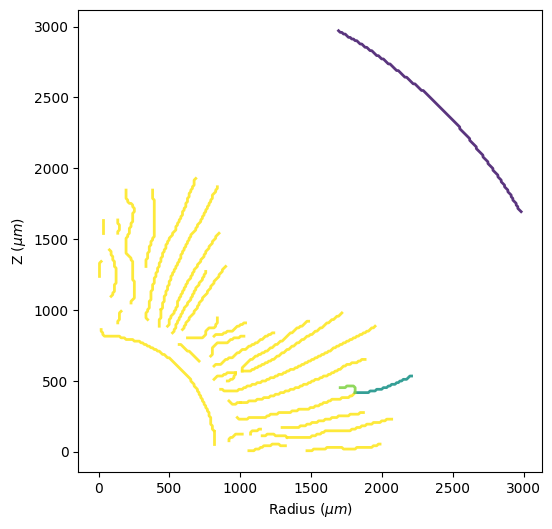

In [ ]:
# 1. Convert your binary skeleton mask into a Skan Skeleton object
# We pass the physical grid spacings so the graph knows its real-world dimensions
spacing_r = rs[1] - rs[0]
spacing_z = zs[1] - zs[0]
skeleton_graph = Skeleton(line_skeleton, spacing=(spacing_z, spacing_r))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_aspect('equal')
#ax.pcolormesh(rc, zc, pre, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin=1.e6, vmax=1.e13))

# 2. Iterate through each independent, continuous path found in the skeleton
for path_idx in range(skeleton_graph.n_paths):
    
    # Extract the ordered pixel coordinates for this specific branch segment
    pixel_coords = skeleton_graph.path_coordinates(path_idx)

    if len(pixel_coords) < 8:
        continue  # Skip segments that are too short to plot
    
    # Convert pixel indices back to your physical grid coordinates (rs and zs)
    # Skan returns coordinates as floating points [row, col]
    rows = pixel_coords[:, 0].astype(int)
    cols = pixel_coords[:, 1].astype(int)
    
    segment_x = rs[cols]
    segment_y = zs[rows]

    values = pre[rows, cols]  # Extract the property values (e.g., pressure) along this segment
    current_property_value = np.average(values)
    average_property_value = np.average(pre)
    
    # 3. Plot each segment individually as a clean vector line and choos color by avraged value along path of defined property (e.g., pressure, density, etc.)
    # Because each segment is extracted along its graph path, it will be perfectly continuous
    ax.plot(segment_x*units.m_to_micron, segment_y*units.m_to_micron, color=plt.cm.viridis(current_property_value/average_property_value), linewidth=2, alpha=0.9, label=f'Segment {path_idx+1}')

ax.set_xlabel(r'Radius ($\mu m$)')
ax.set_ylabel(r'Z ($\mu m$)')

Selected Path #21 with a maximum value of 3.4336e+12


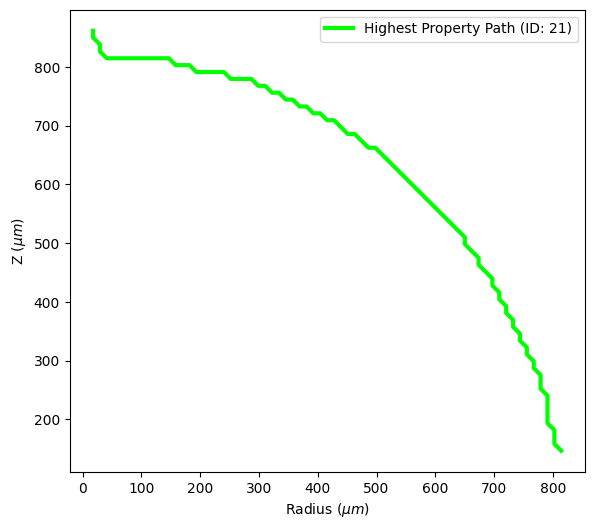

In [ ]:
# select path with highest average pressure along its length
best_path_idx = None
highest_property_value = -float('inf')  # Track the maximum found so far
best_path_coordinates = None

# Loop through all paths identified by skan
for path_idx in range(skeleton_graph.n_paths):
    
    # 1. Extract pixel coordinates for this specific path [row, col]
    pixel_coords = skeleton_graph.path_coordinates(path_idx)

    if len(pixel_coords) < 8:
        continue  # Skip segments that are too short to evaluate
    
    # Convert floating-point path coordinates to integer indices for array indexing
    rows = pixel_coords[:, 0].astype(int)
    cols = pixel_coords[:, 1].astype(int)
    
    # 2. Sample the property values from your 'arr' grid along this path
    values_along_path = pre[rows, cols]
    
    # 3. Calculate your metric of interest for this path.
    # Change 'np.max' to 'np.mean' if you want the highest average value instead.
    current_property_value = np.average(values_along_path)
    
    # 4. Check if this path beats the previous champion
    if current_property_value > highest_property_value:
        highest_property_value = current_property_value
        best_path_idx = path_idx
        
        # Store the physical coordinates for plotting later
        best_path_coordinates = (rs[cols], zs[rows])

# --- Plotting the winning path ---
best_x, best_y = best_path_coordinates

print(f"Selected Path #{best_path_idx} with a maximum value of {highest_property_value:.4e}")

# Plot only the champion path over your background mesh
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_aspect('equal')
ax.plot(best_x*units.m_to_micron, best_y*units.m_to_micron, color='lime', linewidth=3, label=f'Highest Property Path (ID: {best_path_idx})')
ax.set_xlabel(r'Radius ($\mu m$)')
ax.set_ylabel(r'Z ($\mu m$)')
ax.legend()

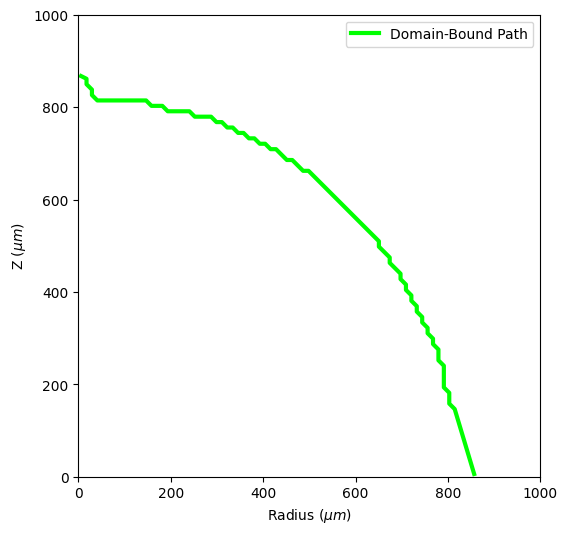

In [ ]:
def extend_path_to_boundaries(x, y, r_min, r_max, z_min, z_max, lookback=5):
    """
    Extrapolates both ends of a path along their current trajectories 
    until they hit the specified grid boundaries.
    """
    # Create editable lists from the coordinates
    ext_x = list(x)
    ext_y = list(y)
    
    # Define bounds dictionary for easier checking
    bounds = {'x_min': r_min, 'x_max': r_max, 'y_min': z_min, 'y_max': z_max}
    
    # Helper to project an endpoint outward along a direction vector
    def project_endpoint(pt_start, pt_prev):
        # Calculate direction vector based on the last few points (lookback)
        direction = pt_start - pt_prev
        norm = np.linalg.norm(direction)
        if norm == 0:
            return None
        dx, dy = direction / norm  # Unit vector
        
        # Determine intersection steps with all 4 boundaries
        steps = []
        if dx > 0: steps.append((bounds['x_max'] - pt_start[0]) / dx)
        if dx < 0: steps.append((bounds['x_min'] - pt_start[0]) / dx)
        if dy > 0: steps.append((bounds['y_max'] - pt_start[1]) / dy)
        if dy < 0: steps.append((bounds['y_min'] - pt_start[1]) / dy)
        
        # The true boundary intersection is the closest positive step
        valid_steps = [s for s in steps if s > 0]
        if not valid_steps:
            return None
        
        min_step = min(valid_steps)
        intersection_point = pt_start + min_step * np.array([dx, dy])
        return intersection_point

    points = np.column_stack((x, y))
    if len(points) < lookback:
        return x, y  # Not enough points to calculate a safe trajectory
    
    # --- 1. Extend the START of the line ---
    pt_start = points[0]
    pt_prev_start = points[min(lookback, len(points)-1)] # Average trajectory looking inward
    new_start = project_endpoint(pt_start, pt_prev_start)
    if new_start is not None:
        ext_x.insert(0, new_start[0])
        ext_y.insert(0, new_start[1])
        
    # --- 2. Extend the END of the line ---
    pt_end = points[-1]
    pt_prev_end = points[-1 - min(lookback, len(points)-1)]
    new_end = project_endpoint(pt_end, pt_prev_end)
    if new_end is not None:
        ext_x.append(new_end[0])
        ext_y.append(new_end[1])
        
    return np.array(ext_x), np.array(ext_y)

# --- Integrated into your selection workflow ---
# Get domain boundary values from your grid arrays
r_min, r_max = rs.min(), rs.max()
z_min, z_max = zs.min(), zs.max()

# Grab your champion path coordinates (ensure they are sequentially sorted!)
best_x, best_y = best_path_coordinates 

# Extrapolate the line to the edges
extended_x, extended_y = extend_path_to_boundaries(best_x, best_y, r_min, r_max, z_min, z_max, lookback=10)

# Plot the fully extended line
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(extended_x*units.m_to_micron, extended_y*units.m_to_micron, color='lime', linewidth=3, label='Domain-Bound Path')

ax.set_aspect('equal')
ax.set_xlabel(r'Radius ($\mu m$)')
ax.set_ylabel(r'Z ($\mu m$)')

ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.legend()

In [ ]:
import numpy as np
from skan import Skeleton
from tqdm import tqdm

class PathAnalyzer:

  def __init__(self, hf5, num_mats=2):
    self.hf5 = hf5
    self.js = index.state_vars(num_mats)

    for ds_name in self.hf5:
      self.rl, self.rh = self.hf5[ds_name][:,:,self.js.rl], self.hf5[ds_name][:,:,self.js.rh]
      self.zl, self.zh = self.hf5[ds_name][:,:,self.js.zl], self.hf5[ds_name][:,:,self.js.zh]
      self.rc, self.zc = 0.5*(self.rl+self.rh), 0.5*(self.zl+self.zh)
      self.vol = self.hf5[ds_name][:,:,self.js.vol]
      break

    self.dr = self.rc[0,1] - self.rc[0,0]
    self.dz = self.zc[1,0] - self.zc[0,0]

    self.r_min, self.r_max = self.rc.min(), self.rc.max()
    self.z_min, self.z_max = self.zc.min(), self.zc.max()

    return
  
  def _select_path(self, line_skeleton, pre):
    # SÉCURITÉ RENFORCÉE : S'il y a moins de 3 pixels True, le squelette est inutile/invalide pour skan
    if np.sum(line_skeleton) < 3:
        return None

    # On encapsule la création dans un try/except au cas où skan rejette la géométrie
    try:
        skeleton_graph = Skeleton(line_skeleton, spacing=(self.dz, self.dr))
    except (ValueError, IndexError):
        return None
    
    best_path_idx = None
    highest_property_value = -float('inf') 
    best_path_coordinates = None

    for path_idx in range(skeleton_graph.n_paths):
      pixel_coords = skeleton_graph.path_coordinates(path_idx)
      
      if len(pixel_coords) < 8:
        continue
      
      rows = pixel_coords[:, 0].astype(int)
      cols = pixel_coords[:, 1].astype(int)
      
      values = pre[rows, cols]
      current_property_value = np.average(values)
      if current_property_value > highest_property_value:
        highest_property_value = current_property_value
        best_path_idx = path_idx
        best_path_coordinates = (self.rc[0,cols], self.zc[rows,0])
    
    if best_path_coordinates is None:
        return None

    xb, yb = best_path_coordinates
    xe, ye = extend_path_to_boundaries(xb, yb, self.r_min, self.r_max, self.z_min, self.z_max, lookback=10)

    return xe, ye
  
  def __call__(self, ds_name):
    ds = self.hf5[ds_name]
    time = get_time(ds)
    pre = ds[:,:,self.js.pre]
    
    ridges = meijering(pre, sigmas=[1, 2], black_ridges=False)
    binary_mask = ridges > np.percentile(ridges, 90)
    line_skeleton = skeletonize(binary_mask)

    return { 'time': time, 'path': self._select_path(line_skeleton, pre) }

# --- EXÉCUTION ---
# Force la réinitialisation de l'instance avec la nouvelle classe
pa = PathAnalyzer(h5f, num_mats=2)

all_results = [pa(ds_name) for ds_name in tqdm(h5f)]
valid_results = [res for res in all_results if res['path'] is not None]
ss = sorted(valid_results, key=lambda x: x['time'])

  0%|          | 0/365 [00:00<?, ?it/s]

100%|██████████| 365/365 [00:40<00:00,  9.01it/s]
